### Farant Marchelino | 2024081012 



### Sel 1: Load Dataset & Pengecekan Awal

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import SelectKBest, f_regression

# Load Dataset
df = pd.read_csv('vgsales.csv')

# Cek missing values
print("--- Jumlah Missing Values ---")
print(df.isnull().sum()[df.isnull().sum() > 0])

--- Jumlah Missing Values ---
Year         271
Publisher     58
dtype: int64


### Feature Engineering 1 - Handling Missing Values

In [3]:
# Mengisi nilai kosong pada 'Year' dengan nilai median
df['Year'] = df['Year'].fillna(df['Year'].median())

# Menghapus baris yang tidak memiliki Publisher (karena jumlahnya sangat sedikit)
df = df.dropna(subset=['Publisher'])

print("--- Pengecekan Missing Values Setelah Imputasi ---")
print(df.isnull().sum().max()) # Jika 0, berarti sudah bersih

--- Pengecekan Missing Values Setelah Imputasi ---
0


### Feature Engineering 2 - Log Transformation

In [4]:
# Memperbaiki distribusi target prediksi (Global_Sales)
# Menggunakan log1p yang merupakan rumus log(1 + x)
df['Log_Global_Sales'] = np.log1p(df['Global_Sales'])

print("--- Perbandingan Nilai Asli vs Log Transform ---")
print(df[['Global_Sales', 'Log_Global_Sales']].head())

--- Perbandingan Nilai Asli vs Log Transform ---
   Global_Sales  Log_Global_Sales
0         82.74          4.427717
1         40.24          3.719409
2         35.82          3.606041
3         33.00          3.526361
4         31.37          3.477232


### Feature Engineering 3 - One-Hot Encoding

In [11]:
df_fe = pd.get_dummies(df, columns=['Genre'], drop_first=True, dtype=int)

print("--- Kolom Baru Hasil One-Hot Encoding ---")
genre_cols = [col for col in df_fe.columns if 'Genre_' in col]
print(df_fe[['Name'] + genre_cols[:4]].head())

--- Kolom Baru Hasil One-Hot Encoding ---
                       Name  Genre_Adventure  Genre_Fighting  Genre_Misc  \
0                Wii Sports                0               0           0   
1         Super Mario Bros.                0               0           0   
2            Mario Kart Wii                0               0           0   
3         Wii Sports Resort                0               0           0   
4  Pokemon Red/Pokemon Blue                0               0           0   

   Genre_Platform  
0               0  
1               1  
2               0  
3               0  
4               0  


### Feature Selection 1 - Correlation Heatmap

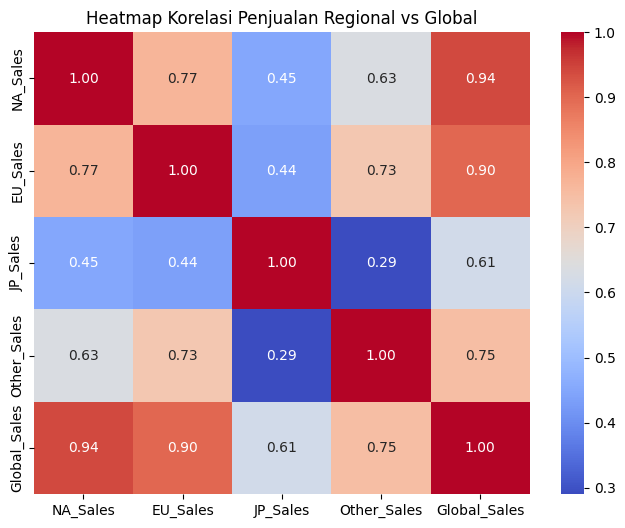

In [10]:
numeric_cols = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']

plt.figure(figsize=(8, 6))
sns.heatmap(df_fe[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Heatmap Korelasi Penjualan Regional vs Global")
plt.show()

### Feature Selection 2 - Univariate Selection (Statistical Scoring)

C:\Users\acer\AppData\Local\Temp\ipykernel_9020\3259620889.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Skor F-Statistic', y='Fitur', data=feature_scores.head(10), palette='viridis')


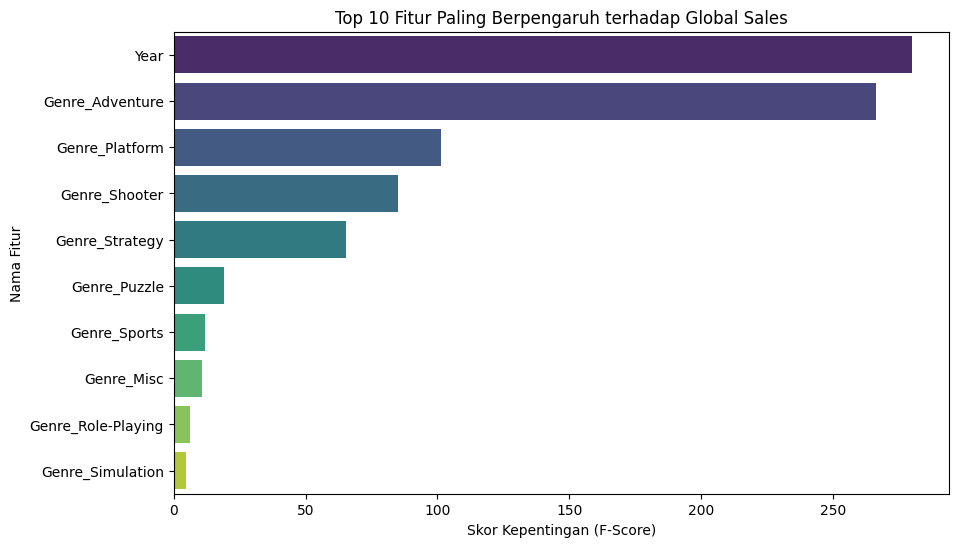

--- Data Tabel Skor Fitur ---
              Fitur  Skor F-Statistic
0              Year        279.874302
1   Genre_Adventure        266.377064
4    Genre_Platform        101.534926
8     Genre_Shooter         85.010585
11   Genre_Strategy         65.517491


In [9]:
X = df_fe.drop(columns=['Rank', 'Name', 'Platform', 'Publisher', 
                        'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 
                        'Global_Sales', 'Log_Global_Sales'])
y = df_fe['Log_Global_Sales']


selector = SelectKBest(score_func=f_regression, k=5)
X_selected = selector.fit_transform(X, y)


feature_scores = pd.DataFrame({
    'Fitur': X.columns,
    'Skor F-Statistic': selector.scores_
}).sort_values(by='Skor F-Statistic', ascending=False)


plt.figure(figsize=(10, 6))
sns.barplot(x='Skor F-Statistic', y='Fitur', data=feature_scores.head(10), palette='viridis')
plt.title("Top 10 Fitur Paling Berpengaruh terhadap Global Sales")
plt.xlabel("Skor Kepentingan (F-Score)")
plt.ylabel("Nama Fitur")
plt.show()

print("--- Data Tabel Skor Fitur ---")
print(feature_scores.head(5))